# 02 · Identity-to-GPU Attack-Path Graph

            An evidence graph that connects users, workloads, containers, GPUs, models, and destinations without claiming exploitability.

## tl;dr

            The compromised fixture produces **33 unique evidence paths** across **41 graph nodes** and **56 edges**. The paths show *where suspicious behavior traveled*; they do not prove a vulnerability was exploited.

## Context & Methods

            Each telemetry row creates observed relationships: identity → workload → container → GPU → model/destination. Only events flagged by bounded evidence rules become attack-path candidates.

            ### Key Assumptions

            - Graph edges represent observed use or connection, not causal compromise.
            - Destinations ending in `.invalid` are safe synthetic external indicators.
            - Duplicate paths are collapsed to keep analyst review bounded.

## Data

Load the same compromised fixture and reproduce the graph from source events.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if not (ROOT / "pyproject.toml").exists():
    raise RuntimeError("Run this notebook from the repository or a child directory")
sys.path.insert(0, str(ROOT / "src"))

NVIDIA = "#76B900"
ORANGE = "#f97316"
BLUE = "#2563eb"
GOLD = "#d9a404"
PINK = "#db2777"
INK = "#172033"
GRID = "#e5e7eb"
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": INK,
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "font.size": 11,
    "axes.titlepad": 30,
})

In [2]:
from collections import Counter
import networkx as nx

from gpu_trust_guardian.graph import build_evidence_graph
from gpu_trust_guardian.pipeline import load_attestation, load_events, analyze_events

events = load_events(ROOT / "data" / "compromised_events.csv")
attestation = load_attestation(ROOT / "attestations" / "untrusted.json")
report = analyze_events(events, attestation, "compromised")
frame = pd.DataFrame([item.to_dict() for item in events])
graph = build_evidence_graph(frame)

pd.DataFrame([{
    "events": len(events), "nodes": graph.number_of_nodes(), "edges": graph.number_of_edges(),
    "unique_attack_paths": len(report.attack_paths), "decision": report.decision,
}])

,events,nodes,edges,unique_attack_paths,decision
0,360,41,56,33,BLOCK


In [3]:
assert graph.number_of_nodes() == report.graph_summary["nodes"]
assert graph.number_of_edges() == report.graph_summary["edges"]
assert all(path[0].startswith("user:") for path in report.attack_paths)
assert len({tuple(path) for path in report.attack_paths}) == len(report.attack_paths)
print("Graph and report reconcile exactly.")

Graph and report reconcile exactly.


## Results

Start with graph composition, then inspect the high-signal paths and their terminal resources.

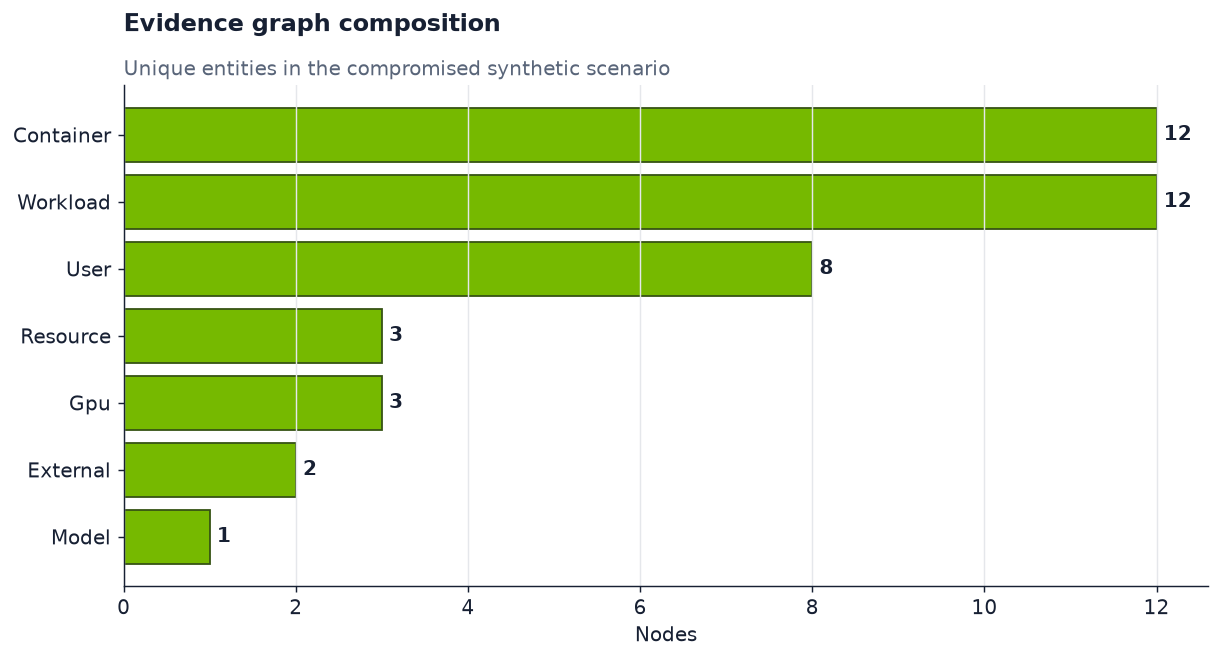

In [4]:
node_counts = Counter(node.split(":", 1)[0] for node in graph.nodes)
node_frame = pd.DataFrame({"node_type": list(node_counts), "nodes": list(node_counts.values())}).sort_values("nodes")
fig, ax = plt.subplots(figsize=(9.5, 5.2))
bars = ax.barh(node_frame["node_type"].str.title(), node_frame["nodes"], color=NVIDIA, edgecolor="#365314")
ax.bar_label(bars, padding=4, fontweight="bold")
ax.set_title("Evidence graph composition", loc="left", fontweight="bold")
ax.text(0, 1.02, "Unique entities in the compromised synthetic scenario", transform=ax.transAxes, color="#596579")
ax.set_xlabel("Nodes")
ax.grid(axis="x", color=GRID, linewidth=.8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

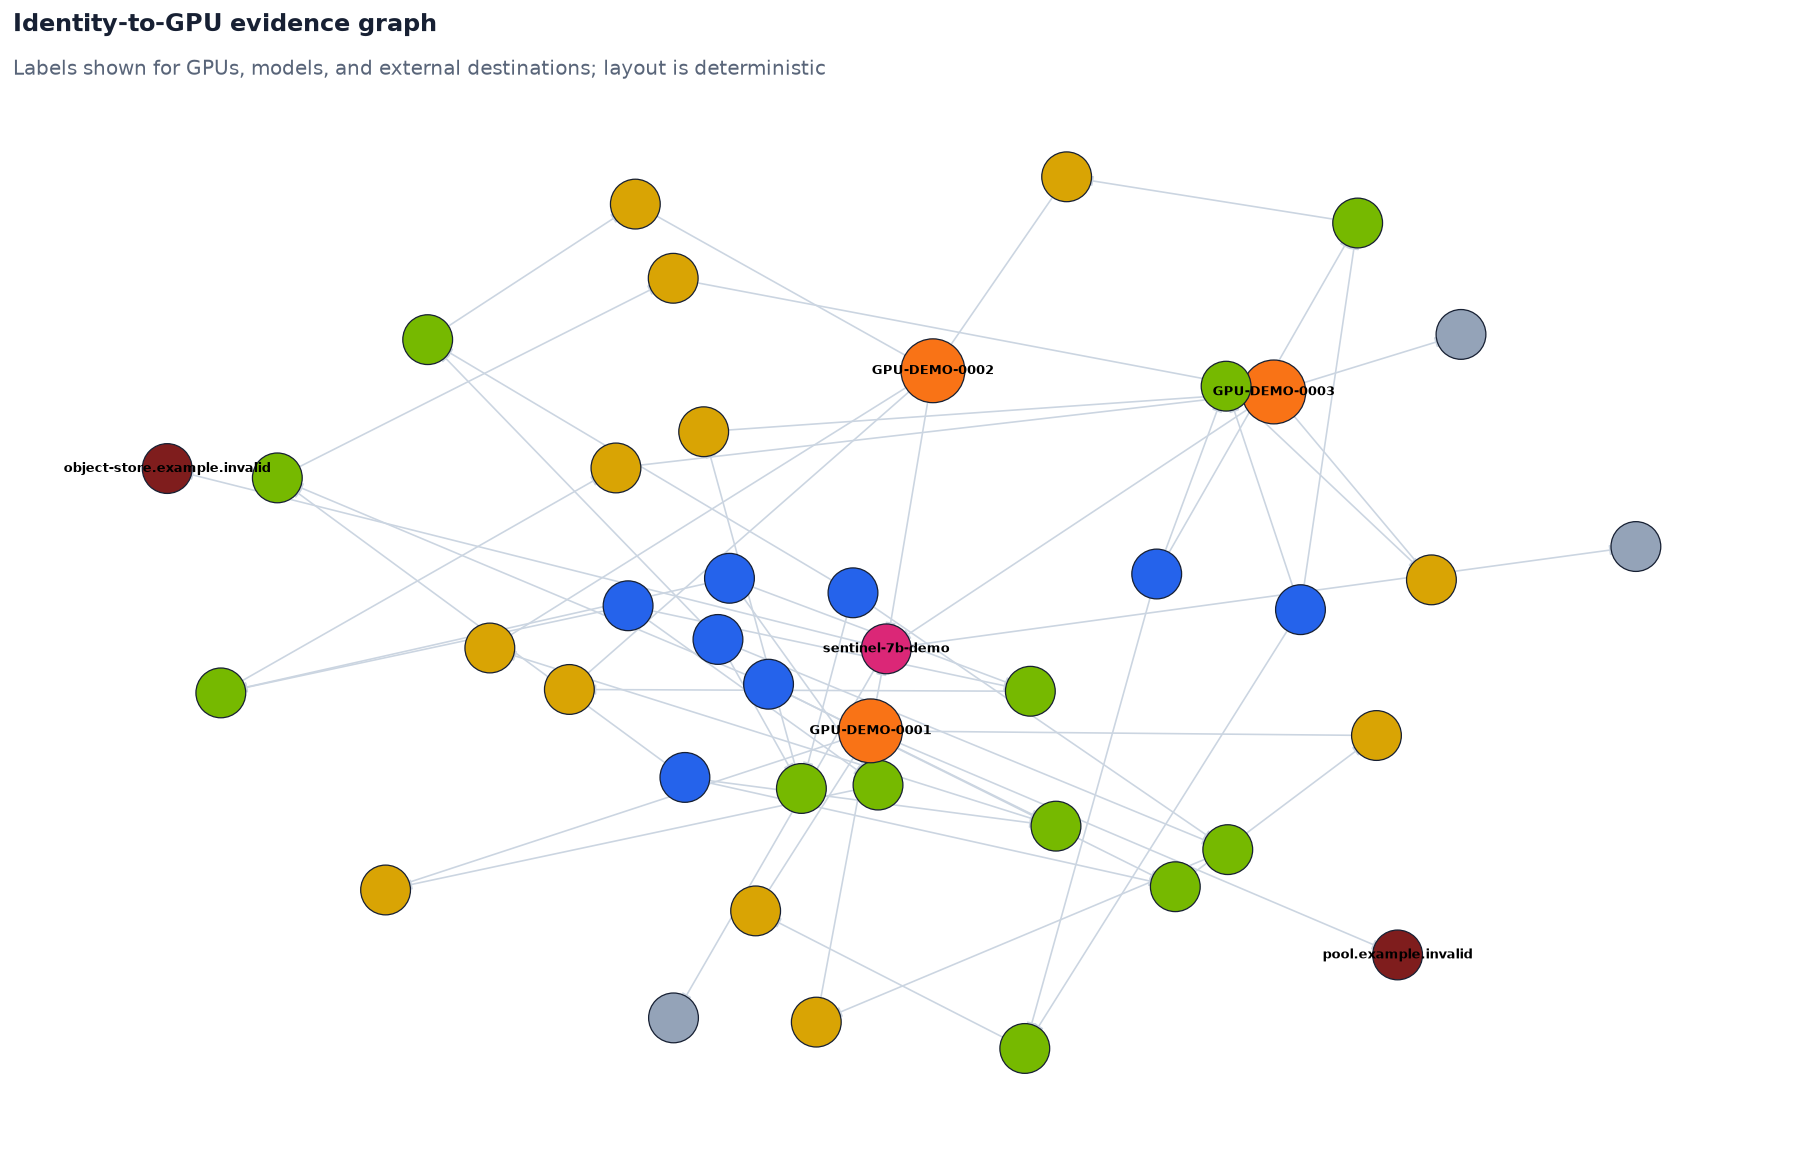

In [5]:
color_map = {
    "user": BLUE, "workload": NVIDIA, "container": GOLD, "gpu": ORANGE,
    "model": PINK, "external": "#7f1d1d", "resource": "#94a3b8",
}
positions = nx.spring_layout(graph, seed=42, k=0.72)
colors = [color_map.get(node.split(":", 1)[0], "#cbd5e1") for node in graph.nodes]
sizes = [1250 if node.startswith("gpu:") else 760 for node in graph.nodes]

fig, ax = plt.subplots(figsize=(14, 9))
nx.draw_networkx_edges(graph, positions, ax=ax, edge_color="#cbd5e1", arrows=True, arrowsize=12, width=.9)
nx.draw_networkx_nodes(graph, positions, ax=ax, node_color=colors, node_size=sizes, edgecolors=INK, linewidths=.7)
labels = {node: node.split(":", 1)[1] for node in graph.nodes if node.startswith(("gpu:", "model:", "external:"))}
nx.draw_networkx_labels(graph, positions, labels=labels, ax=ax, font_size=7, font_weight="bold")
ax.set_title("Identity-to-GPU evidence graph", loc="left", fontweight="bold")
ax.text(0, 1.01, "Labels shown for GPUs, models, and external destinations; layout is deterministic", transform=ax.transAxes, color="#596579")
ax.axis("off")
plt.tight_layout()
plt.show()

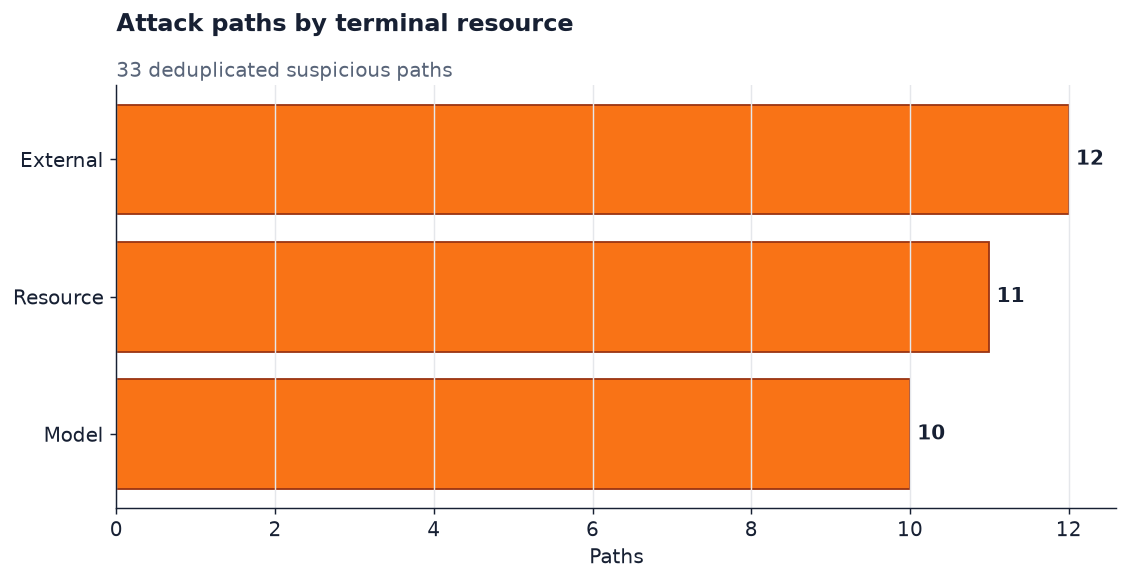

,terminal,paths
0,model,10
2,resource,11
1,external,12


In [6]:
terminal_counts = Counter(path[-1].split(":", 1)[0] for path in report.attack_paths)
terminal_frame = pd.DataFrame({"terminal": list(terminal_counts), "paths": list(terminal_counts.values())}).sort_values("paths")
fig, ax = plt.subplots(figsize=(8.8, 4.6))
bars = ax.barh(terminal_frame["terminal"].str.title(), terminal_frame["paths"], color=ORANGE, edgecolor="#9a3412")
ax.bar_label(bars, padding=4, fontweight="bold")
ax.set_title("Attack paths by terminal resource", loc="left", fontweight="bold")
ax.text(0, 1.02, f"{len(report.attack_paths)} deduplicated suspicious paths", transform=ax.transAxes, color="#596579")
ax.set_xlabel("Paths")
ax.grid(axis="x", color=GRID, linewidth=.8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
terminal_frame

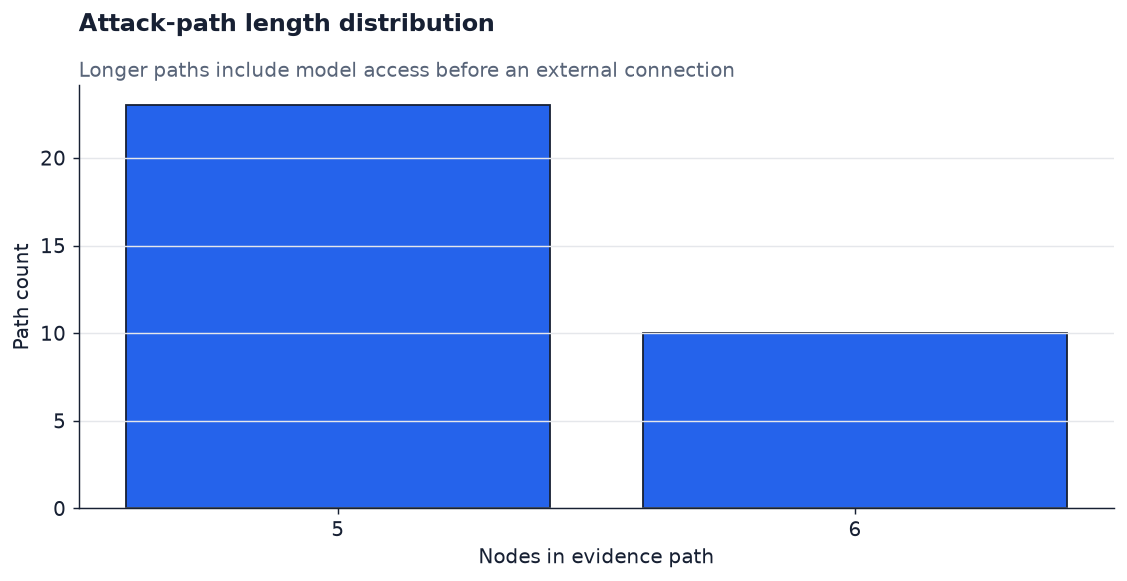

In [7]:
lengths = pd.Series([len(path) for path in report.attack_paths], name="nodes_in_path")
fig, ax = plt.subplots(figsize=(8.8, 4.6))
bins = np.arange(lengths.min() - .5, lengths.max() + 1.5, 1)
ax.hist(lengths, bins=bins, color=BLUE, edgecolor=INK, rwidth=.82)
ax.set_xticks(sorted(lengths.unique()))
ax.set_xlabel("Nodes in evidence path")
ax.set_ylabel("Path count")
ax.set_title("Attack-path length distribution", loc="left", fontweight="bold")
ax.text(0, 1.02, "Longer paths include model access before an external connection", transform=ax.transAxes, color="#596579")
ax.grid(axis="y", color=GRID, linewidth=.8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Takeaways

            1. **Graph context makes alerts actionable.** The report preserves **33** identity-to-resource paths instead of returning isolated scores.
            2. **The graph is evidence, not exploit proof.** Every edge is traceable to synthetic telemetry, but reachability alone does not establish compromise.
            3. **Containment can target the narrowest node.** Analysts can quarantine a workload or identity before considering a broader GPU/node response.